In [13]:
# PHASE 1: INGEST & AUDIT DATA

import pandas as pd

# 1. Load the downloaded local CPCB Indian Air Quality CSV file
df = pd.read_csv("indian_air_quality.csv")

# 2. Inspect overall dataset dimensions (Rows, Columns)
print("Dataset Shape (Rows, Columns):", df.shape)

# 3. Preview the first 5 rows of the raw dataset to verify column names and values
df.head()

# 4. Display column data types, non-null counts, and memory usage to check structure
df.info()

# 5. Count the total number of missing (NaN) values in each column
df.isnull().sum()

# 6. Generate summary statistics (mean, std, min, max, percentiles) for numeric columns
df.describe()

Dataset Shape (Rows, Columns): (31861, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31861 entries, 0 to 31860
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Timestamp  31861 non-null  object 
 1   PM2.5      31861 non-null  float64
dtypes: float64(1), object(1)
memory usage: 498.0+ KB


,PM2.5
count,31861.000000
mean,47.603671
std,24.341598
min,7.020000
25%,26.450000
50%,43.720000
75%,63.610000
max,245.630000


In [14]:
# PHASE 2: DATA WRANGLING & FEATURE ENGINEERING

# 1. Parse string Timestamps into true Pandas date-time objects
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d-%m-%Y %H:%M')

# 2. Extract temporal dimensions for time-series aggregation
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Hour'] = df['Timestamp'].dt.hour
df['Day_of_Week'] = df['Timestamp'].dt.day_name()

# 3. Verify object-to-datetime conversion
print("\nUpdated Data Types:\n", df.dtypes)

# 4. Preview the first 5 rows again to confirm the new engineered columns were added
df.head()


Updated Data Types:
 Timestamp      datetime64[ns]
PM2.5                 float64
Year                    int32
Month                   int32
Hour                    int32
Day_of_Week            object
dtype: object


,Timestamp,PM2.5,Year,Month,Hour,Day_of_Week
0,2018-01-01 00:00:00,90.19,2018,1,0,Monday
1,2018-01-01 01:00:00,86.98,2018,1,1,Monday
2,2018-01-01 02:00:00,86.06,2018,1,2,Monday
3,2018-01-01 03:00:00,94.04,2018,1,3,Monday
4,2018-01-01 04:00:00,108.78,2018,1,4,Monday


In [15]:
# PHASE 3: AGGREGATION & TIME-SERIES INSIGHTS

# 1. Average PM2.5 levels by Hour of the day (Rush hour impact)
hourly_pm25 = df.groupby('Hour')['PM2.5'].mean().reset_index()
print("--- Average PM2.5 by Hour ---")
print(hourly_pm25.sort_values(by='PM2.5', ascending=False).head())

# 2. Average PM2.5 levels by Month (Seasonal impact)
monthly_pm25 = df.groupby('Month')['PM2.5'].mean().reset_index()
print("\n--- Average PM2.5 by Month ---")
print(monthly_pm25)

# 3. Average PM2.5 levels by Day of Week (Weekday vs Weekend)
weekly_pm25 = df.groupby('Day_of_Week')['PM2.5'].mean().reset_index()
print("\n--- Average PM2.5 by Day of Week ---")
print(weekly_pm25)

--- Average PM2.5 by Hour ---
    Hour      PM2.5
18    18  54.317363
19    19  54.120371
17    17  53.669757
20    20  52.784130
5      5  51.908798

--- Average PM2.5 by Month ---
    Month      PM2.5
0       1  79.058611
1       2  63.731634
2       3  51.180488
3       4  42.686136
4       5  34.736199
5       6  28.584127
6       7  23.010724
7       8  21.702044
8       9  24.627094
9      10  47.602640
10     11  69.364684
11     12  74.411399

--- Average PM2.5 by Day of Week ---
  Day_of_Week      PM2.5
0      Friday  47.239025
1      Monday  47.635672
2    Saturday  47.125207
3      Sunday  46.634546
4    Thursday  47.733391
5     Tuesday  48.258944
6   Wednesday  48.590040


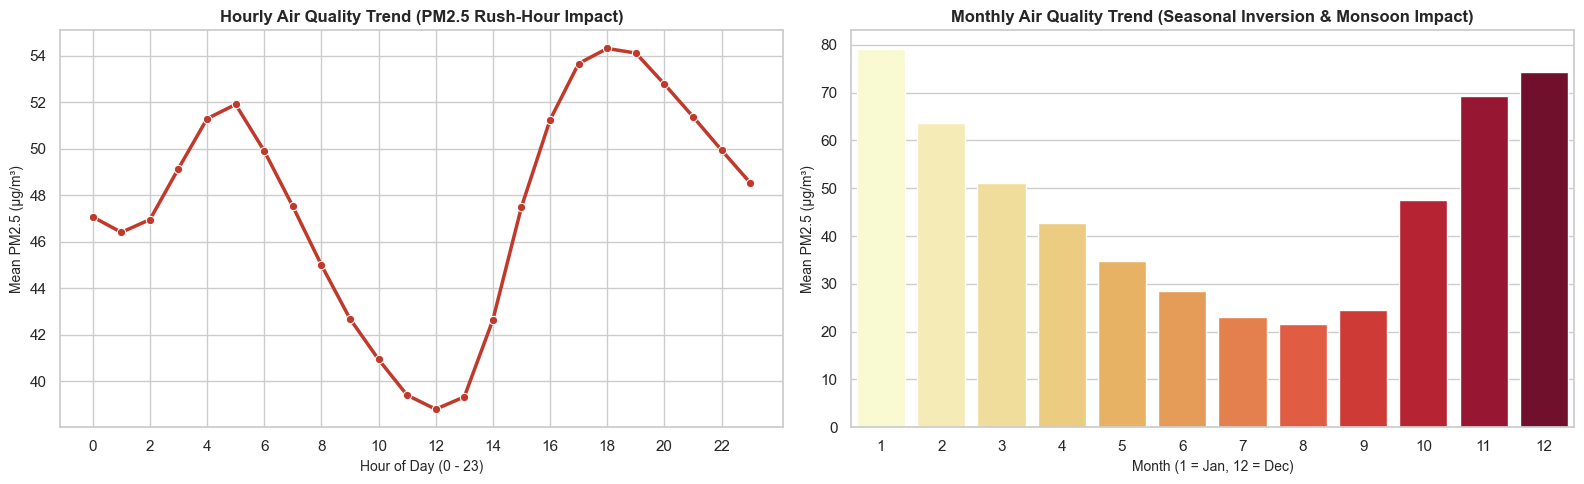

In [20]:
# PHASE 4: DATA VISUALIZATION

import matplotlib.pyplot as plt
import seaborn as sns

# Set overall style theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 5))

# ------------------------------------------------------------------------------
# Subplot 1: Hourly PM2.5 Trend (Line Plot)
# ------------------------------------------------------------------------------

plt.subplot(1, 2, 1)

# Plot line showing the diurnal cycle (rush-hour peaks)
sns.lineplot(
    data=hourly_pm25, 
    x='Hour', 
    y='PM2.5', 
    marker='o', 
    color='#C0392B', 
    linewidth=2.5
)

# Labeling and axis adjustments
plt.title('Hourly Air Quality Trend (PM2.5 Rush-Hour Impact)', fontsize=12, fontweight='bold')
plt.xlabel('Hour of Day (0 - 23)', fontsize=10)
plt.ylabel('Mean PM2.5 (µg/m³)', fontsize=10)
plt.xticks(range(0, 24, 2))

# ------------------------------------------------------------------------------
# Subplot 2: Monthly PM2.5 Trend (Bar Plot)
# ------------------------------------------------------------------------------

plt.subplot(1, 2, 2)

# Plot bar chart showing seasonal shift (Winter peak vs. Monsoon low)
sns.barplot(
    data=monthly_pm25, 
    x='Month', 
    y='PM2.5', 
    hue='Month',       # Updated to fix Seaborn warning
    legend=False,      # Prevents unnecessary duplicate legend
    palette='YlOrRd'
)

# Labeling and axis adjustments
plt.title('Monthly Air Quality Trend (Seasonal Inversion & Monsoon Impact)', fontsize=12, fontweight='bold')
plt.xlabel('Month (1 = Jan, 12 = Dec)', fontsize=10)
plt.ylabel('Mean PM2.5 (µg/m³)', fontsize=10)

plt.tight_layout()
plt.show()